# M3 PCA - Analisis de componentes principales
**Input:** data/processed/df_clean.csv
**Output:** Decision justificada de que variables originales pasan a M4

# 0. Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import sys
sys.path.insert(0, "..")

from src.pca_analysis import preparar_para_pca

# 1. Cargar df_clean

In [9]:
df_clean = pd.read_csv("../data/processed/df_clean.csv")

print(f"Shape: {df_clean.shape}")
print(f"Columnas: {df_clean.columns.tolist()}")

Shape: (116, 46)
Columnas: ['SEXO DON', 'EDAD DON ', 'EDAD REC', 'DOSIS DE          G-CSF', 'DÍAS DE          G-CSF', 'PESO DON', 'TALLA DON', 'IMC DON', 'PESO REC.', 'CEBADO', 'VOLEMIA mL', 'DESECHABLE', ' RH DONADOR', 'CMV  IgM DONADOR', 'CMV IgG DONADOR', ' RH RECEPTOR', 'CMV  IgM RECEPTOR', 'CMV IgG RECEPTOR', 'PRE WBC  k/µL ', 'PRE MNC%', 'PRE MNC k/µL', 'PRE HTO %', 'PRE PLT k/μL', 'CD34+ /µL DÍA 4', 'CD34+ /µL DÍA 5', 'TIPO_ALOGÉNICO', 'TIPO_AUTÓLOGO', 'TIPO_HAPLOIDÉNTICO', 'ESTIMULACION_PEGILADO', 'MAQUINA_EMT-25', 'MAQUINA_EMT-50', 'MAQUINA_EMT-68', 'ACCESO_AMO', 'ACCESO_CATÉTER', 'ACCESO_PUNCIÓN', 'EVENTO_ADV', 'ABO_DON_A', 'ABO_DON_AB', 'ABO_DON_B', 'ABO_DON_O', 'ABO_REC_A', 'ABO_REC_AB', 'ABO_REC_B', 'ABO_REC_O', 'PLERIXAFOR_DADO', 'Processed WB (liters)']


# 2. Preparar para PCA
Dos pasos:
1. Drop CD34+ (35% NaN)
2. Drop en filas restantes -> aprox. 110 filas limpias

In [10]:
X, y, idx = preparar_para_pca(df_clean, verbose=True)

[prep] Filas iniciales   : 116
[prep] Features iniciales: 45

[prep] Dropped 'CD34+ /µL DÍA 4' (35% NaN, timing de medición)
[prep] Features tras drop: 44

[prep] Columnas con NaN  : ['CEBADO', 'VOLEMIA mL', 'CMV  IgM RECEPTOR', 'CMV IgG RECEPTOR', 'PRE WBC  k/µL ', 'PRE MNC%', 'PRE MNC k/µL', 'PRE HTO %', 'PRE PLT k/μL', 'CD34+ /µL DÍA 5', 'MAQUINA_EMT-25', 'MAQUINA_EMT-50', 'MAQUINA_EMT-68', 'ABO_REC_A', 'ABO_REC_AB', 'ABO_REC_B', 'ABO_REC_O']
[prep] Filas eliminadas  : 6

[prep] Shape final → X: (110, 44) | y: 110 filas
[prep] NaN en X: 0 (debe ser 0)
[prep] NaN en y: 0 (debe ser 0)


# 3. Estandarizar (z-score)
PCA es sensible a escala - obligatorio antes de correr

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Shape X_scaled: {X_scaled.shape}")
print(f"Media (debe ser aprox. 0): {X_scaled.mean().abs().max():.6f}")
print(f"Std (debe ser aprox. 1): {X_scaled.std().max():.6f}")

Shape X_scaled: (110, 44)
Media (debe ser aprox. 0): 0.000000
Std (debe ser aprox. 1): 1.004577


# 4. Heatmap de correlación
Antes de PCA, revisamos correlaciones directas entre las features

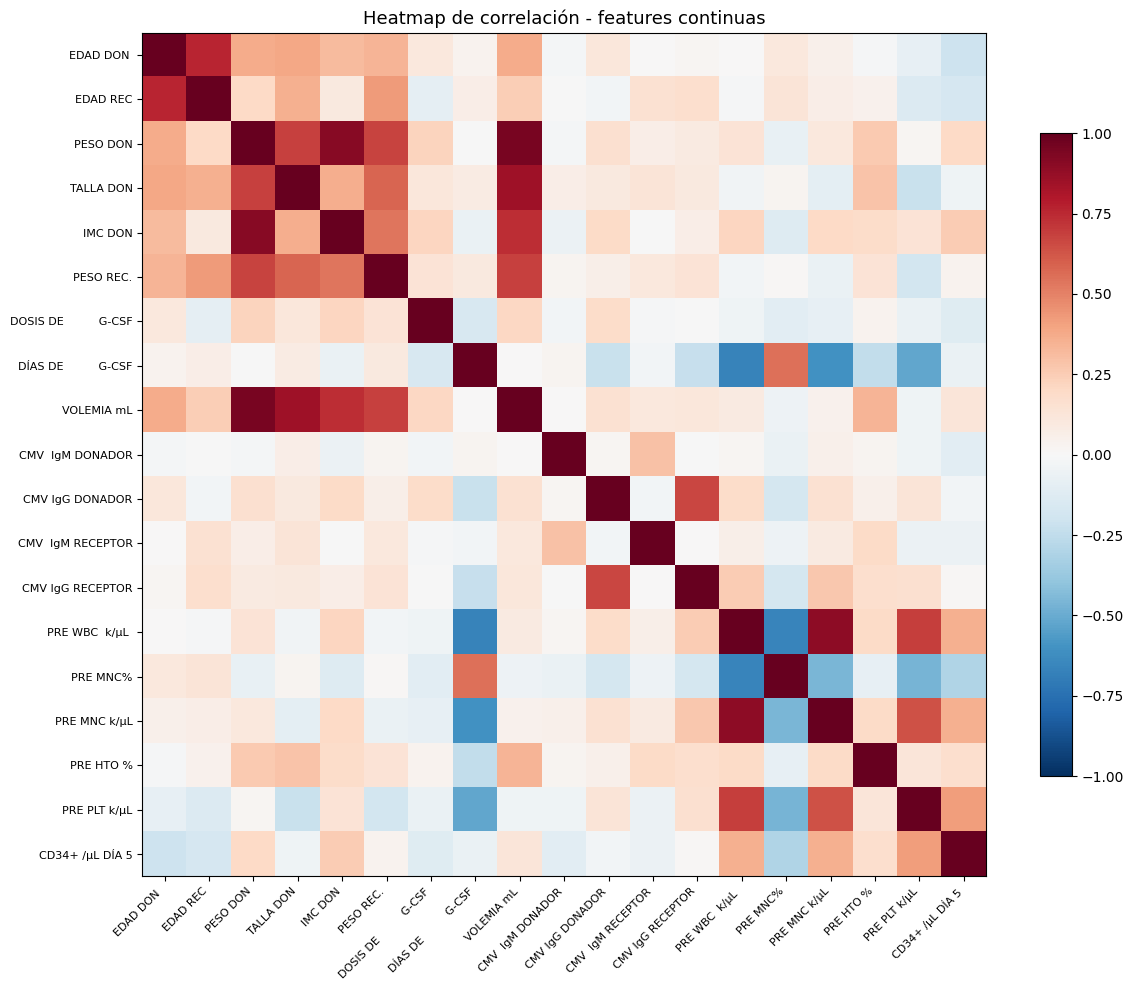


Pares con |correlación| > 0.7:
  'EDAD DON '                         <-> 'EDAD REC'                           r=0.758
  'PESO DON'                          <-> 'IMC DON'                            r=0.908
  'PESO DON'                          <-> 'VOLEMIA mL'                         r=0.947
  'TALLA DON'                         <-> 'VOLEMIA mL'                         r=0.845
  'IMC DON'                           <-> 'VOLEMIA mL'                         r=0.741
  'PRE WBC  k/µL '                    <-> 'PRE MNC k/µL'                       r=0.897


In [12]:
# Seleccionar solo columnas continuas (excluir binarias y one-hot)
cols_continuas = [
    "EDAD DON ", "EDAD REC",
    "PESO DON", "TALLA DON", "IMC DON", "PESO REC.",
    "DOSIS DE          G-CSF", "DÍAS DE          G-CSF",
    "VOLEMIA mL",
    "CMV  IgM DONADOR", "CMV IgG DONADOR",
    "CMV  IgM RECEPTOR", "CMV IgG RECEPTOR",
    "PRE WBC  k/µL ", "PRE MNC%", "PRE MNC k/µL", "PRE HTO %", "PRE PLT k/μL",
    "CD34+ /µL DÍA 5",
]
# Filtrar solo las que existen en X (por si alguna fue dropeada)
cols_continuas = [c for c in cols_continuas if c in X.columns]

corr = X[cols_continuas].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cols_continuas)))
ax.set_yticks(range(len(cols_continuas)))
ax.set_xticklabels(cols_continuas, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(cols_continuas, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Heatmap de correlación - features continuas", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/m3_heatmap_correlacion.png", dpi=150)
plt.show()

# Pares con |corr| > 0.7
print("\nPares con |correlación| > 0.7:")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        v = corr.iloc[i, j]
        if abs(v) > 0.7:
            print(f"  {corr.columns[i]!r:35s} <-> {corr.columns[j]!r:35s}  r={v:.3f}")

# 5. Correr PCA

In [13]:
pca = PCA()
pca.fit(X_scaled)

var = pca.explained_variance_ratio_
cumvar = np.cumsum(var)
n_components = len(var)

print(f"Total de componentes: {n_components}")
for threshold in [0.80, 0.90, 0.95]:
    n = int(np.argmax(cumvar >= threshold)) + 1
    print(f"  {threshold*100:.0f}% varianza explicada -> {n} componentes")

Total de componentes: 44
  80% varianza explicada -> 14 componentes
  90% varianza explicada -> 20 componentes
  95% varianza explicada -> 24 componentes


# 6. Scree plot + varianza acumulada

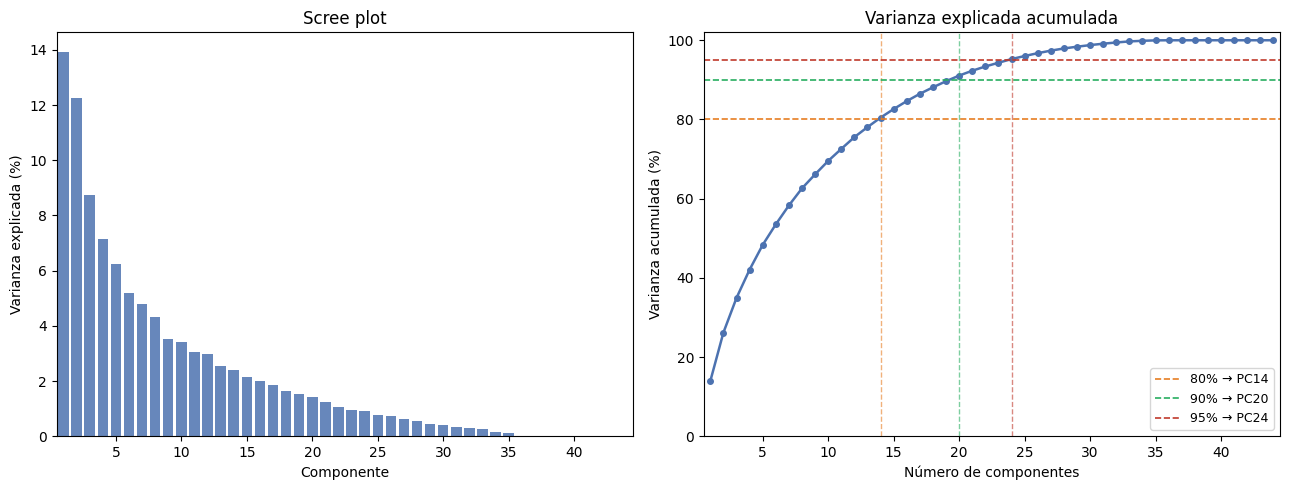

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
ax1.bar(range(1, n_components + 1), var * 100, color="#4C72B0", alpha=0.85)
ax1.set_xlabel("Componente")
ax1.set_ylabel("Varianza explicada (%)")
ax1.set_title("Scree plot")
ax1.set_xlim(0.5, n_components + 0.5)

# Varianza acumulada
ax2.plot(range(1, n_components + 1), cumvar * 100,
         marker="o", markersize=4, color="#4C72B0", linewidth=1.8)

for threshold, color in [(0.80, "#e67e22"), (0.90, "#27ae60"), (0.95, "#c0392b")]:
    n = int(np.argmax(cumvar >= threshold)) + 1
    ax2.axhline(threshold * 100, color=color, linestyle="--", linewidth=1.2,
                label=f"{threshold*100:.0f}% → PC{n}")
    ax2.axvline(n, color=color, linestyle="--", linewidth=1.0, alpha=0.6)

ax2.set_xlabel("Número de componentes")
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_title("Varianza explicada acumulada")
ax2.legend(fontsize=9)
ax2.set_xlim(0.5, n_components + 0.5)
ax2.set_ylim(0, 102)

plt.tight_layout()
plt.savefig("../outputs/figures/m3_scree_plot.png", dpi=150)
plt.show()

# 7. Tabla de loadings (top variables por componente)
Los loadings indican cuanto contribuye cada variable original a cada PC.
Loading alto (positivo o negativo) = esa variable "pesa" en ese componente

In [15]:
N_PCS = 6  # cuántos PCs mostrar en la tabla

loadings_df = pd.DataFrame(
    pca.components_[:N_PCS].T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(N_PCS)]
)

# Mostrar top 8 variables por PC (ordenadas por |loading|)
for pc in loadings_df.columns:
    top = loadings_df[pc].abs().sort_values(ascending=False).head(8)
    print(f"=== {pc} ({var[int(pc[2:])-1]*100:.1f}% var) ===")
    for col in top.index:
        print(f"  {loadings_df.loc[col, pc]:+.3f}  {col}")
    print()

=== PC1 (13.9% var) ===
  +0.268  PRE WBC  k/µL 
  -0.260  TIPO_AUTÓLOGO
  +0.258  VOLEMIA mL
  +0.257  PESO DON
  +0.240  IMC DON
  +0.240  PRE MNC k/µL
  -0.224  DÍAS DE          G-CSF
  +0.219  SEXO DON

=== PC2 (12.2% var) ===
  +0.320  TALLA DON
  +0.303  VOLEMIA mL
  +0.301  PESO REC.
  +0.274  PESO DON
  -0.262  CEBADO
  +0.253  EDAD DON 
  -0.244  PRE PLT k/μL
  +0.231  TIPO_AUTÓLOGO

=== PC3 (8.8% var) ===
  +0.414  ABO_REC_O
  +0.412  ABO_DON_O
  -0.354  ABO_REC_A
  -0.329  ABO_DON_A
  +0.241   RH RECEPTOR
  -0.213  ABO_DON_AB
  +0.203   RH DONADOR
  -0.200  ABO_REC_AB

=== PC4 (7.1% var) ===
  +0.358  PLERIXAFOR_DADO
  -0.307  ABO_DON_AB
  +0.292   RH RECEPTOR
  -0.291  ABO_REC_AB
  +0.250   RH DONADOR
  +0.235  CMV IgG RECEPTOR
  +0.226  EDAD REC
  +0.214  CMV IgG DONADOR

=== PC5 (6.2% var) ===
  +0.414  ACCESO_PUNCIÓN
  -0.414  ACCESO_CATÉTER
  +0.351  ABO_REC_B
  +0.292  ABO_DON_B
  -0.247  EVENTO_ADV
  +0.207  MAQUINA_EMT-50
  -0.200  ABO_DON_O
  +0.176   RH RECEPTOR

=

# 8. Biplot (PC1 vs PC2)

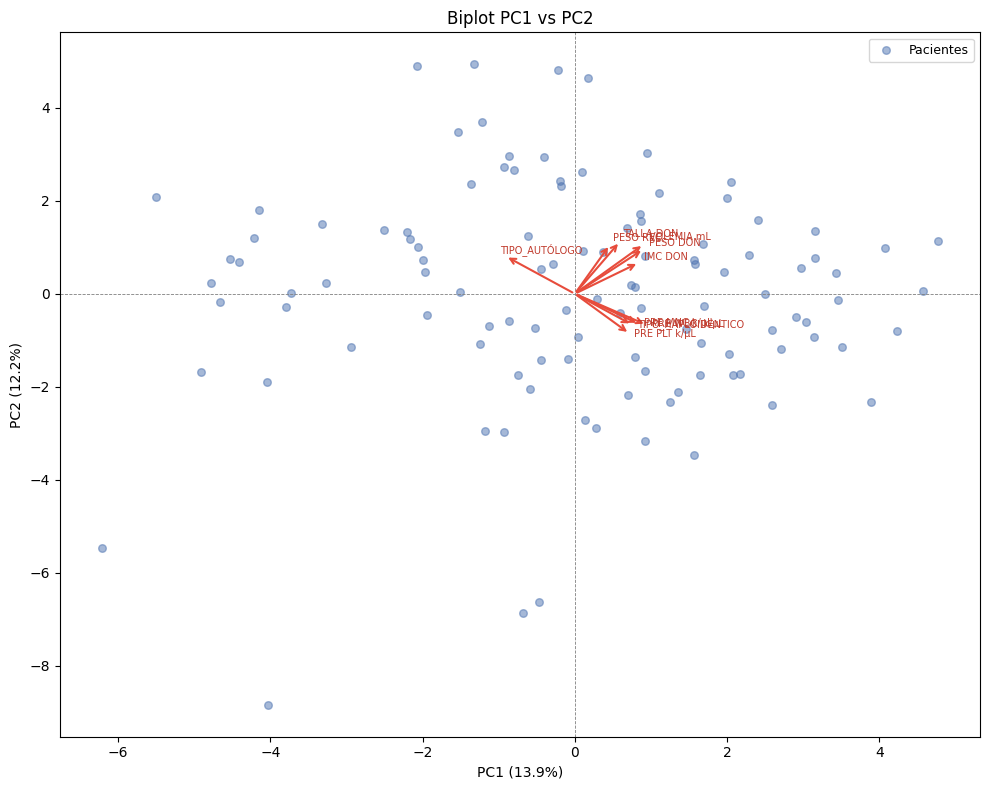

In [16]:
scores = pca.transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

# Puntos (observaciones)
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.5, s=30, color="#4C72B0", label="Pacientes")

# Flechas (loadings) - solo las top 10 por magnitud en PC1+PC2
magnitudes = np.sqrt(loadings_df["PC1"]**2 + loadings_df["PC2"]**2)
top_vars = magnitudes.sort_values(ascending=False).head(10).index

scale = 3.5  # escala visual de las flechas
for var_name in top_vars:
    lx = loadings_df.loc[var_name, "PC1"] * scale
    ly = loadings_df.loc[var_name, "PC2"] * scale
    ax.annotate(
        "",
        xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5)
    )
    ax.text(lx * 1.08, ly * 1.08, var_name, fontsize=7, color="#c0392b")

ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax.set_title("Biplot PC1 vs PC2")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/m3_biplot.png", dpi=150)
plt.show()

## 9. Decisión: variables que pasan a M4

### Observaciones del scree plot
La varianza cae gradualmente (PC1=13.9%, PC2=12.2%, PC3=8.8%...).

### Interpretación de componentes principales
| PC | Var | Tema dominante |
|---|---|---|
| PC1 | 13.9% | Tamaño del donador: PRE WBC, VOLEMIA, PESO DON, IMC DON |
| PC2 | 12.2% | Morfología: TALLA DON, VOLEMIA, PESO DON, PESO REC |
| PC3 | 8.8%  | Grupo sanguíneo ABO (donador/receptor) |
| PC4 | 7.1%  | Plerixafor + serología CMV/RH |
| PC5 | 6.2%  | Tipo de acceso vascular (PUNCIÓN vs CATÉTER) |
| PC6 | 5.2%  | ABO subtipo A vs B |

### Decisión de variables para M4

**Drops por redundancia confirmada por heatmap + loadings:**

| Variable | Motivo |
|---|---|
| `EDAD REC` | r=0.964 con EDAD DON; no aparece en top loadings de ningún PC relevante |
| `IMC DON` | = PESO/TALLA²; carga en PC1 junto a PESO DON → mismo eje |
| `PESO REC.` | r=0.792 con PESO DON; carga en PC2 junto a PESO DON y VOLEMIA |
| `PRE MNC k/µL` | = PRE WBC × PRE MNC%; carga en PC1 junto a PRE WBC → drop el derivado |
| `CMV IgM RECEPTOR` | r=1.0 con CMV IgM DONADOR |
| `CMV IgG RECEPTOR` | r=0.926 con CMV IgG DONADOR |
| `ACCESO_*` | Domina PC5 pero es variable intra-procedimiento, no predice WB pre-aféresis |

**Conservar (44 → 36 features aprox):** todo lo demás, incluyendo
`VOLEMIA mL`, `PESO DON`, `TALLA DON`, `EDAD DON`, `PRE WBC`, `PRE MNC%`,
`CMV IgM DONADOR`, `CMV IgG DONADOR`, `PLERIXAFOR_DADO`, `CD34+ /µL DÍA 5`,
`PRE HTO %`, `PRE PLT k/μL`, todas las dummies de TIPO, MAQUINA, ABO, RH,
`SEXO DON`, `DOSIS/DÍAS G-CSF`, `CEBADO`, `DESECHABLE`, `EVENTO_ADV`.